<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/KKRC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data=pd.read_csv('/content/KlekotaRothCount.csv')
data

,Name,KRFPC1,KRFPC2,KRFPC3,KRFPC4,KRFPC5,KRFPC6,KRFPC7,KRFPC8,KRFPC9,...,KRFPC4852,KRFPC4853,KRFPC4854,KRFPC4855,KRFPC4856,KRFPC4857,KRFPC4858,KRFPC4859,KRFPC4860,bioactivity_class
0,CHEMBL167155,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,inactive
1,CHEMBL166740,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,inactive
2,CHEMBL165038,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,inactive
3,CHEMBL435857,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,inactive
4,CHEMBL352783,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive


In [ ]:
data.dtypes

,0
Name,object
KRFPC1,int64
KRFPC2,int64
KRFPC3,int64
KRFPC4,int64
...,...
KRFPC4857,int64
KRFPC4858,int64
KRFPC4859,int64
KRFPC4860,int64


In [ ]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-3-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-3-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,Name,KRFPC1,KRFPC2,KRFPC3,KRFPC4,KRFPC5,KRFPC6,KRFPC7,KRFPC8,KRFPC9,...,KRFPC4852,KRFPC4853,KRFPC4854,KRFPC4855,KRFPC4856,KRFPC4857,KRFPC4858,KRFPC4859,KRFPC4860,class
0,CHEMBL167155,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,N
1,CHEMBL166740,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,N
2,CHEMBL165038,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,N
3,CHEMBL435857,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,N
4,CHEMBL352783,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
data.isnull().sum().sum()

0

In [ ]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [ ]:
data1 = data.iloc[:,1:4861]
data1
data2 = data.iloc[:,-1]

In [ ]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)

In [ ]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,KRFPC1,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC20,KRFPC72,KRFPC92,KRFPC126,...,KRFPC4770,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4829,KRFPC4830,KRFPC4843,KRFPC4853
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,2
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1225,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,KRFPC1,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC20,KRFPC72,KRFPC92,KRFPC126,...,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4829,KRFPC4830,KRFPC4843,KRFPC4853,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,N
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,2,N
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,N
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,N
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
1225,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
## remove features that display high correlation with many other features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.9:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1

{'KRFPC20',
 'KRFPC2949',
 'KRFPC302',
 'KRFPC3025',
 'KRFPC303',
 'KRFPC3058',
 'KRFPC307',
 'KRFPC314',
 'KRFPC3224',
 'KRFPC3295',
 'KRFPC3302',
 'KRFPC3336',
 'KRFPC3369',
 'KRFPC3375',
 'KRFPC3388',
 'KRFPC3394',
 'KRFPC3395',
 'KRFPC3402',
 'KRFPC3404',
 'KRFPC341',
 'KRFPC3418',
 'KRFPC3440',
 'KRFPC3455',
 'KRFPC346',
 'KRFPC347',
 'KRFPC348',
 'KRFPC3593',
 'KRFPC3640',
 'KRFPC3646',
 'KRFPC3647',
 'KRFPC3648',
 'KRFPC3649',
 'KRFPC3655',
 'KRFPC3657',
 'KRFPC3659',
 'KRFPC3660',
 'KRFPC3662',
 'KRFPC3671',
 'KRFPC3692',
 'KRFPC3693',
 'KRFPC3701',
 'KRFPC3706',
 'KRFPC3707',
 'KRFPC3709',
 'KRFPC3712',
 'KRFPC3716',
 'KRFPC3718',
 'KRFPC3719',
 'KRFPC3721',
 'KRFPC3722',
 'KRFPC3725',
 'KRFPC3727',
 'KRFPC3730',
 'KRFPC3731',
 'KRFPC3733',
 'KRFPC3737',
 'KRFPC3738',
 'KRFPC3740',
 'KRFPC3742',
 'KRFPC3744',
 'KRFPC3746',
 'KRFPC3750',
 'KRFPC3752',
 'KRFPC3757',
 'KRFPC3764',
 'KRFPC3773',
 'KRFPC3775',
 'KRFPC3777',
 'KRFPC3781',
 'KRFPC3782',
 'KRFPC3783',
 'KRFPC3785',
 '

In [ ]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [ ]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,KRFPC1,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC72,KRFPC92,KRFPC126,KRFPC133,...,KRFPC4757,KRFPC4763,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4830,KRFPC4853,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,N
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,N
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,N
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,N
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N
1225,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
data3.to_csv('KKRC.csv')

In [ ]:
X = data3.iloc[:,1:161]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
X

,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC72,KRFPC92,KRFPC126,KRFPC133,KRFPC297,...,KRFPC4752,KRFPC4757,KRFPC4763,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4830,KRFPC4853
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1225,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1226,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1227,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC72,KRFPC92,KRFPC126,KRFPC133,KRFPC297,...,KRFPC4752,KRFPC4757,KRFPC4763,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4830,KRFPC4853
0,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,-0.416199,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,2.806072
1,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,-0.416199,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,5.901819
2,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,-0.416199,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,2.806072
3,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,-0.416199,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,2.806072
4,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,-0.416199,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,2.806072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,1.817461,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,-0.289675
1225,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,1.817461,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,-0.289675
1226,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,1.817461,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,-0.289675
1227,-0.370896,-0.32087,-0.128268,-0.337168,-0.335928,-0.244045,-0.22452,1.817461,-0.329104,-0.94943,...,-0.340669,-0.257631,-0.227638,-0.26578,-0.251096,-0.237833,-0.128804,-0.198858,-0.143177,-0.289675


In [ ]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(860, 160)
(860,)
(369, 160)
(369,)


In [ ]:
X_train

,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC72,KRFPC92,KRFPC126,KRFPC133,KRFPC297,...,KRFPC4752,KRFPC4757,KRFPC4763,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4830,KRFPC4853
387,0,0,0,0,0,0,0,1,0,2,...,0,0,0,0,0,0,0,0,0,1
250,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
378,3,0,0,2,0,0,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1185,0,0,1,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,1,0,1,0,19,...,0,0,0,0,0,0,0,0,0,0
1180,0,0,1,0,0,0,0,1,1,6,...,0,0,0,0,0,0,0,0,0,0
1147,3,0,0,0,2,1,0,0,0,14,...,0,1,0,0,0,0,0,0,0,0
527,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [ ]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set

,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC72,KRFPC92,KRFPC126,KRFPC133,KRFPC297,...,KRFPC4757,KRFPC4763,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4830,KRFPC4853,class
387,0,0,0,0,0,0,0,1,0,2,...,0,0,0,0,0,0,0,0,1,N
250,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
378,3,0,0,2,0,0,0,0,0,7,...,0,0,0,0,0,0,0,0,0,N
73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1185,0,0,1,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,1,0,1,0,19,...,0,0,0,0,0,0,0,0,0,N
1180,0,0,1,0,0,0,0,1,1,6,...,0,0,0,0,0,0,0,0,0,P
1147,3,0,0,0,2,1,0,0,0,14,...,1,0,0,0,0,0,0,0,0,N
527,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,1,P


In [ ]:
Training_set.to_csv('KleKotaRothCount_Training_set.csv')

In [ ]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,KRFPC2,KRFPC14,KRFPC16,KRFPC17,KRFPC18,KRFPC72,KRFPC92,KRFPC126,KRFPC133,KRFPC297,...,KRFPC4757,KRFPC4763,KRFPC4810,KRFPC4811,KRFPC4821,KRFPC4824,KRFPC4826,KRFPC4830,KRFPC4853,class
693,3,0,0,2,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
834,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
1016,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,P
1113,0,1,0,0,0,0,0,2,2,1,...,0,0,0,0,0,0,0,0,0,P
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,1,P
909,0,1,0,0,0,0,1,0,0,7,...,0,0,0,0,0,0,0,0,0,P
270,0,1,0,0,1,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,N
349,1,3,1,1,2,1,0,0,0,10,...,0,0,0,0,0,0,1,0,0,P


In [ ]:
Testing_set.to_csv('KleKotaRothCount_Testing_set.csv')

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape

(860, 15)

In [ ]:
kBest.get_support(True)

array([ 25,  28,  33,  46,  48,  50,  55,  94, 105, 107, 120, 132, 138,
       139, 140])

In [ ]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns

Index(['KRFPC647', 'KRFPC677', 'KRFPC1154', 'KRFPC2265', 'KRFPC2547',
       'KRFPC2667', 'KRFPC2975', 'KRFPC3609', 'KRFPC3699', 'KRFPC3704',
       'KRFPC3779', 'KRFPC3998', 'KRFPC4139', 'KRFPC4260', 'KRFPC4269'],
      dtype='object')

In [ ]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [ ]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores


,Features,Scores
0,KRFPC2,0.037276
1,KRFPC14,0.022675
2,KRFPC16,0.014246
3,KRFPC17,0.000000
4,KRFPC18,0.014370
...,...,...
155,KRFPC4821,0.025794
156,KRFPC4824,0.000024
157,KRFPC4826,0.016824
158,KRFPC4830,0.030051


In [ ]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

      Features    Scores
55   KRFPC2975  0.104413
94   KRFPC3609  0.092839
132  KRFPC3998  0.070441
140  KRFPC4269  0.070117
25    KRFPC647  0.064253
50   KRFPC2667  0.061863
107  KRFPC3704  0.061317
48   KRFPC2547  0.049556
105  KRFPC3699  0.044986
120  KRFPC3779  0.043672
28    KRFPC677  0.043301
138  KRFPC4139  0.042757
46   KRFPC2265  0.042013
139  KRFPC4260  0.041509
33   KRFPC1154  0.041364


In [ ]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
55,KRFPC2975,0.104413
94,KRFPC3609,0.092839
132,KRFPC3998,0.070441
140,KRFPC4269,0.070117
25,KRFPC647,0.064253
50,KRFPC2667,0.061863
107,KRFPC3704,0.061317
48,KRFPC2547,0.049556
105,KRFPC3699,0.044986
120,KRFPC3779,0.043672


In [ ]:
Graph.to_csv('KleKotaRothCount_Features.csv')

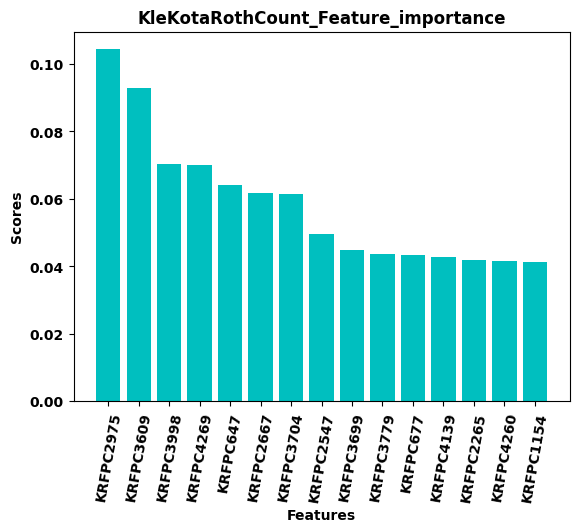

<Figure size 1000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
data = pd.read_csv('KleKotaRothCount_Features.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title("KleKotaRothCount_Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [ ]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,KRFPC647,KRFPC677,KRFPC1154,KRFPC2265,KRFPC2547,KRFPC2667,KRFPC2975,KRFPC3609,KRFPC3699,KRFPC3704,KRFPC3779,KRFPC3998,KRFPC4139,KRFPC4260,KRFPC4269,class
387,0,1,0,0,0,0,5,0,0,0,0,0,0,0,0,N
250,0,1,1,0,0,0,5,0,0,0,0,0,0,0,0,N
378,0,1,0,0,1,0,13,0,2,0,0,0,0,0,0,N
73,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,N
1185,0,2,0,0,2,1,6,0,0,0,2,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,1,0,27,0,0,0,0,0,0,0,0,N
1180,0,2,0,1,2,1,16,0,0,2,2,0,1,0,0,P
1147,0,0,3,0,1,0,28,0,0,0,0,0,0,0,0,N
527,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,P


In [ ]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,KRFPC647,KRFPC677,KRFPC1154,KRFPC2265,KRFPC2547,KRFPC2667,KRFPC2975,KRFPC3609,KRFPC3699,KRFPC3704,KRFPC3779,KRFPC3998,KRFPC4139,KRFPC4260,KRFPC4269
693,0,0,0,0,1,0,6,0,2,0,0,0,0,0,0
834,0,0,0,0,1,1,2,0,0,0,0,0,0,0,0
1016,0,2,0,0,2,2,6,0,0,0,0,1,1,0,1
1113,1,0,0,0,5,3,12,0,0,0,0,1,0,0,0
31,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,0,0,0,0,5,0,0,0,0,0,0,0,0
909,0,1,0,2,1,0,16,3,0,0,1,0,0,0,2
270,0,1,1,0,0,0,9,0,0,0,0,0,0,0,0
349,0,1,2,3,2,1,39,0,0,1,0,0,0,0,0


In [ ]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,KRFPC647,KRFPC677,KRFPC1154,KRFPC2265,KRFPC2547,KRFPC2667,KRFPC2975,KRFPC3609,KRFPC3699,KRFPC3704,KRFPC3779,KRFPC3998,KRFPC4139,KRFPC4260,KRFPC4269,class
693,0,0,0,0,1,0,6,0,2,0,0,0,0,0,0,N
834,0,0,0,0,1,1,2,0,0,0,0,0,0,0,0,N
1016,0,2,0,0,2,2,6,0,0,0,0,1,1,0,1,P
1113,1,0,0,0,5,3,12,0,0,0,0,1,0,0,0,P
31,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,0,0,0,0,5,0,0,0,0,0,0,0,0,P
909,0,1,0,2,1,0,16,3,0,0,1,0,0,0,2,P
270,0,1,1,0,0,0,9,0,0,0,0,0,0,0,0,N
349,0,1,2,3,2,1,39,0,0,1,0,0,0,0,0,P


In [ ]:
Trainset.to_csv('Trainset_KleKotaRothCount_after_feature.csv')
Testset.to_csv('Testset_KleKotaRothCount_after_feature.csv')

In [ ]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-56-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-56-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,KRFPC647,KRFPC677,KRFPC1154,KRFPC2265,KRFPC2547,KRFPC2667,KRFPC2975,KRFPC3609,KRFPC3699,KRFPC3704,KRFPC3779,KRFPC3998,KRFPC4139,KRFPC4260,KRFPC4269,class
387,0,1,0,0,0,0,5,0,0,0,0,0,0,0,0,0
250,0,1,1,0,0,0,5,0,0,0,0,0,0,0,0,0
378,0,1,0,0,1,0,13,0,2,0,0,0,0,0,0,0
73,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
1185,0,2,0,0,2,1,6,0,0,0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,1,0,27,0,0,0,0,0,0,0,0,0
1180,0,2,0,1,2,1,16,0,0,2,2,0,1,0,0,1
1147,0,0,3,0,1,0,28,0,0,0,0,0,0,0,0,0
527,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,1


In [ ]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-57-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-57-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,KRFPC647,KRFPC677,KRFPC1154,KRFPC2265,KRFPC2547,KRFPC2667,KRFPC2975,KRFPC3609,KRFPC3699,KRFPC3704,KRFPC3779,KRFPC3998,KRFPC4139,KRFPC4260,KRFPC4269,class
693,0,0,0,0,1,0,6,0,2,0,0,0,0,0,0,0
834,0,0,0,0,1,1,2,0,0,0,0,0,0,0,0,0
1016,0,2,0,0,2,2,6,0,0,0,0,1,1,0,1,1
1113,1,0,0,0,5,3,12,0,0,0,0,1,0,0,0,1
31,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1


In [ ]:
Trainset.to_csv('Trainset1_KleKotaRothCount_after_feature.csv')
Testset.to_csv('Testset1_KleKotaRothCount_after_feature.csv')